# Pytorch Introduction with Linear Regression Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Linear Regression with Gradient Descent in Numpy

Text(0.5, 1.0, 'train dataset')

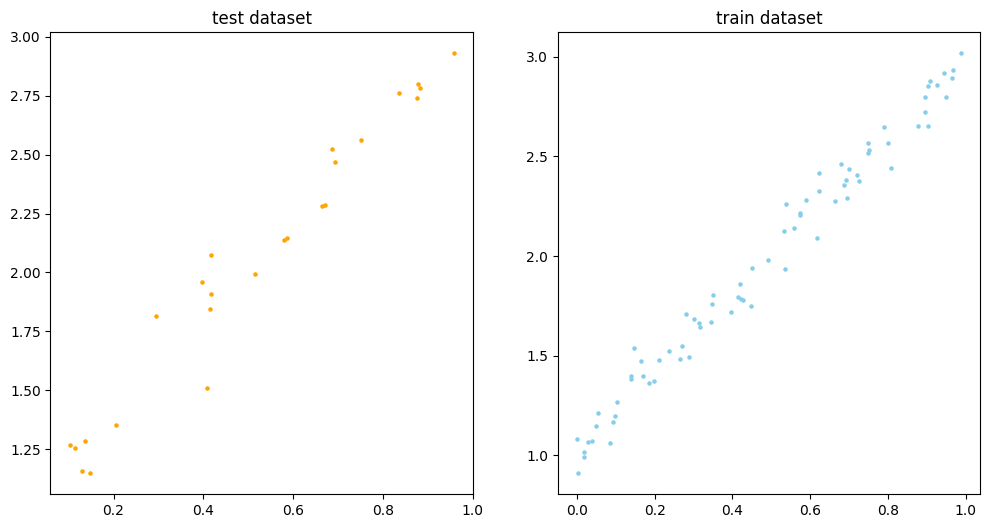

In [2]:
# initialize model
def line(a, b, x):
    return a * x + b

# generate data
np.random.seed(1)
x = 1 * np.random.rand(1000, 1)
y = 2 * x + 1 + 0.1 * np.random.randn(1000, 1)

# generate indices and shuffle them for train/test set
idx = np.arange(100)
np.random.shuffle(idx)

# train/test indices
train_idx = idx[:75]
test_idx = idx[75:]

# create trai/test split
x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

# plot data
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].set_title("test dataset")
ax[1].set_title("train dataset")

In [3]:
# random slope and intercept
epochs = 500
batch = 5
lr = 1e-2

m = np.random.randn(1)
q = np.random.randn(1)

print("m before training: ", m)
print("q before training: ", q)
print()

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    mse_batch = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))

        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]

        y_pred = line(m, q, x_train_batch)
        error = y_train_batch - y_pred

        mse = error ** 2

        q_grad = -2 * error.mean()
        m_grad = -2 * (x_train_batch * error).mean()

        m = m - m_grad * lr
        q = q - q_grad * lr

        print(f"Loss: {mse.mean()}")
        mse_batch.append(mse)
    train_history.append(np.array(mse_batch).mean())
    print()


print("m after training: ", m)
print("q after training: ", q)
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

m before training:  [-0.2669303]
q before training:  [0.70915717]

Epoch: 1
Batch: 1/5
Loss: 3.0993185609569265
Batch: 2/5
Loss: 2.0624090808303444
Batch: 3/5
Loss: 1.8608825638549886
Batch: 4/5
Loss: 1.520985317541819
Batch: 5/5
Loss: 2.2912234144806423

Epoch: 2
Batch: 1/5
Loss: 2.5198315394329414
Batch: 2/5
Loss: 1.637787125832055
Batch: 3/5
Loss: 1.4842352347513066
Batch: 4/5
Loss: 1.1870173603210168
Batch: 5/5
Loss: 1.84806000883628

Epoch: 3
Batch: 1/5
Loss: 2.0619185860342166
Batch: 2/5
Loss: 1.308799040349595
Batch: 3/5
Loss: 1.19390397817725
Batch: 4/5
Loss: 0.9318631536936504
Batch: 5/5
Loss: 1.5000403105703737

Epoch: 4
Batch: 1/5
Loss: 1.6993252561226597
Batch: 2/5
Loss: 1.0539216153072863
Batch: 3/5
Loss: 0.9702474918948513
Batch: 4/5
Loss: 0.7373370923466567
Batch: 5/5
Loss: 1.2263380589984103

Epoch: 5
Batch: 1/5
Loss: 1.4115482564133193
Batch: 2/5
Loss: 0.8564578106931324
Batch: 3/5
Loss: 0.798055623176417
Batch: 4/5
Loss: 0.5893862289551826
Batch: 5/5
Loss: 1.010723815

Text(0.5, 1.0, 'train loss')

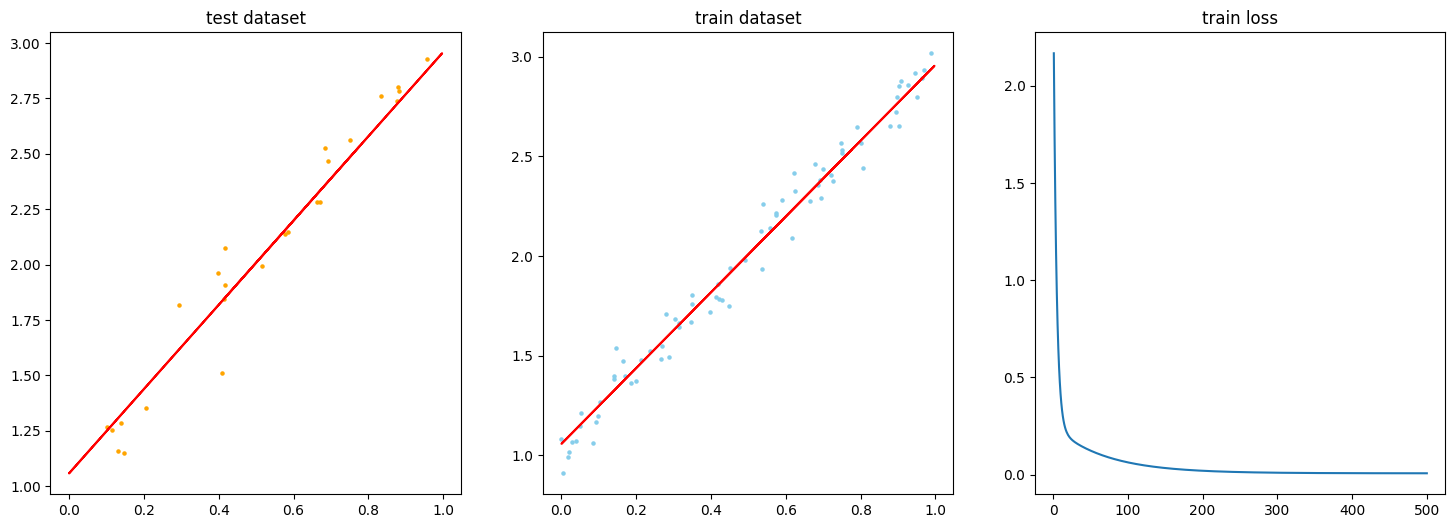

In [4]:
# use learned coeff
y_pred = line(m, q, x)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x, y_pred, c="red")
ax[1].plot(x, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

## Linear Regression with Gradient Descent in PyTorch

In [5]:
import torch
import torch.optim as optim
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
# convert data into tensors
x_tensor = torch.from_numpy(x).float().to(device)
y_tensor = torch.from_numpy(y).float().to(device)

print(type(x))
print(type(x_tensor))
print(x_tensor.type())

<class 'numpy.ndarray'>
<class 'torch.Tensor'>
torch.FloatTensor
